# 📊 Day 01 — First Look at the Data
## Project: Loan Default Predictor | Give Me Some Credit Dataset

---
**Goal today:** Load the dataset, understand its shape, find obvious problems, and write down what you observe like a data detective.

**Time estimate:** 1.5 – 2 hours

**What you will do:**
1. Install & import libraries
2. Load data
3. Understand shape + columns
4. Check data types
5. Statistical summary
6. Missing values scan
7. Target variable check
8. Write your observations (THIS IS IMPORTANT)

> 💡 **Rule #1:** Every cell must have a markdown cell above it explaining WHY you are running that code. Interviewers read notebooks top-to-bottom like a story.

---
## SECTION 0 — Dataset Info (Read Before Coding)

**Dataset:** Give Me Some Credit (Kaggle Competition)

**Download link:** https://www.kaggle.com/c/GiveMeSomeCredit/data

**Files you need:**
- `cs-training.csv` → this is your main dataset (150,000 rows)
- `cs-test.csv` → ignore for now

**Business Context:**
Banks need to predict whether a borrower will face serious financial distress (miss payments for 90+ days) in the next 2 years.
If the model is good → bank lends to safe people → less money lost.

**Column Dictionary:**

| Column | Meaning |
|---|---|
| `SeriousDlqin2yrs` | **TARGET** — 1 = defaulted, 0 = did not default |
| `RevolvingUtilizationOfUnsecuredLines` | How much of credit limit is being used (0 to 1+) |
| `age` | Age of borrower |
| `NumberOfTime30-59DaysPastDueNotWorse` | Times 30-59 days late on payment |
| `DebtRatio` | Monthly debt payments / monthly gross income |
| `MonthlyIncome` | Monthly income in USD |
| `NumberOfOpenCreditLinesAndLoans` | Open loans + lines of credit |
| `NumberOfTimes90DaysLate` | Times 90+ days late |
| `NumberRealEstateLoansOrLines` | Mortgage + real estate loans |
| `NumberOfTime60-89DaysPastDueNotWorse` | Times 60-89 days late |
| `NumberOfDependents` | Number of dependents (family members) |

> ⚠️ **Important:** Put `cs-training.csv` in the same folder as this notebook before running.

---
## SECTION 1 — Import Libraries

We import only what we need today. Do NOT import everything blindly.
Each library has a specific job:
- `pandas` → load and manipulate tabular data
- `numpy` → numerical operations
- `matplotlib` + `seaborn` → visualization
- `warnings` → suppress irrelevant warnings so output is clean

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Make plots look clean
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

✅ All libraries imported successfully
Pandas version: 2.3.3
Numpy version: 2.3.5


---
## SECTION 2 — Load the Dataset

We load the training CSV. The first column is just an index Kaggle added — we tell pandas to use it as the index so it doesn't appear as a feature.

**What we check immediately after loading:**
- Did it load without errors?
- How many rows and columns?
- Does it look right?

In [2]:
# Load dataset — index_col=0 drops the unnamed first column (row numbers from Kaggle)
df = pd.read_csv('cs-training.csv', index_col=0)

print(f'✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Dataset loaded successfully!
Shape: 150,000 rows × 11 columns


In [3]:
# Always look at the first 5 rows to sanity-check the data
# This is the FIRST thing every data scientist does
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Last 5 rows — sometimes files have footer rows or formatting issues at the end
df.tail()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0
150000,0,0.850283,64,0,0.249908,8158.0,8,0,2,0,0.0


---
## SECTION 3 — Understand Shape & Column Names

Before touching the data, we need to know exactly what we're working with.
Think of this as reading the table of contents of a book before diving in.

In [5]:
print('=== DATASET DIMENSIONS ===')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print()
print('=== COLUMN NAMES ===')
for i, col in enumerate(df.columns):
    print(f'  [{i:02d}] {col}')

=== DATASET DIMENSIONS ===
Rows    : 150,000
Columns : 11

=== COLUMN NAMES ===
  [00] SeriousDlqin2yrs
  [01] RevolvingUtilizationOfUnsecuredLines
  [02] age
  [03] NumberOfTime30-59DaysPastDueNotWorse
  [04] DebtRatio
  [05] MonthlyIncome
  [06] NumberOfOpenCreditLinesAndLoans
  [07] NumberOfTimes90DaysLate
  [08] NumberRealEstateLoansOrLines
  [09] NumberOfTime60-89DaysPastDueNotWorse
  [10] NumberOfDependents


---
## SECTION 4 — Data Types (`.info()`)

`.info()` is one of the most important commands. It tells us:
1. Data type of each column (int, float, object)
2. How many non-null values each column has → reveals missing data
3. Memory usage

> ⚠️ **Watch for:** Any column that should be numeric but shows as `object` — that means there's a string hiding in the data.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

### ✍️ YOUR OBSERVATIONS — Data Types

*(Fill this in after running the cell above)*

- All columns appear to be: `float64` / `int64` (no text columns — good!)
- Columns with missing values visible here: *(write which ones)*
- Total memory used: *(write from output)*

> 📝 **Why this matters for interviews:** Being able to say "I noticed column X had only 120,269 non-null values out of 150,000 — that's a 20% missing rate" shows you actually understand the data.

---
## SECTION 5 — Statistical Summary (`.describe()`)

`.describe()` gives us for every numeric column:
- count, mean, std, min, max
- 25th, 50th (median), 75th percentile

**What to look for:**
- min values that are negative (impossible for age, income)
- max values that are absurdly large (outliers)
- mean vs median gap (signals skewness)

In [7]:
# Transpose (.T) so columns become rows — easier to read with many columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.07,0.25,0.0,0.00,0.00,0.00,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.05,249.76,0.0,0.03,0.15,0.56,50708.0
age,150000.0,52.30,14.77,0.0,41.00,52.00,63.00,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.42,4.19,0.0,0.00,0.00,0.00,98.0
DebtRatio,150000.0,353.01,2037.82,0.0,0.18,0.37,0.87,329664.0
MonthlyIncome,120269.0,6670.22,14384.67,0.0,3400.00,5400.00,8249.00,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.45,5.15,0.0,5.00,8.00,11.00,58.0
NumberOfTimes90DaysLate,150000.0,0.27,4.17,0.0,0.00,0.00,0.00,98.0
NumberRealEstateLoansOrLines,150000.0,1.02,1.13,0.0,0.00,1.00,2.00,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.24,4.16,0.0,0.00,0.00,0.00,98.0


In [8]:
# Look specifically at min and max for red flags
print('=== MIN VALUES (looking for impossible negatives) ===')
print(df.min())
print()
print('=== MAX VALUES (looking for outliers) ===')
print(df.max())

=== MIN VALUES (looking for impossible negatives) ===
SeriousDlqin2yrs                        0.0
RevolvingUtilizationOfUnsecuredLines    0.0
age                                     0.0
NumberOfTime30-59DaysPastDueNotWorse    0.0
DebtRatio                               0.0
MonthlyIncome                           0.0
NumberOfOpenCreditLinesAndLoans         0.0
NumberOfTimes90DaysLate                 0.0
NumberRealEstateLoansOrLines            0.0
NumberOfTime60-89DaysPastDueNotWorse    0.0
NumberOfDependents                      0.0
dtype: float64

=== MAX VALUES (looking for outliers) ===
SeriousDlqin2yrs                              1.0
RevolvingUtilizationOfUnsecuredLines      50708.0
age                                         109.0
NumberOfTime30-59DaysPastDueNotWorse         98.0
DebtRatio                                329664.0
MonthlyIncome                           3008750.0
NumberOfOpenCreditLinesAndLoans              58.0
NumberOfTimes90DaysLate                      98.0
Numb

### ✍️ YOUR OBSERVATIONS — Statistical Summary

*(Fill this in after running the cells above)*

**Suspicious findings I noticed:**
- `age` min is ___. Is age = 0 possible? → Likely a data error.
- `RevolvingUtilizationOfUnsecuredLines` max is ___. Over 100% utilization means someone spent beyond their limit.
- `DebtRatio` max is ___. This seems unrealistically high. Flag for Day 3 (outliers).
- `MonthlyIncome` mean is ___ but median is ___. The gap = income is right-skewed (few very rich people pulling the mean up).

**Write one business insight here:**
*(Example: "People in this dataset have an average age of 52. This is an older lending population.")*

---
## SECTION 6 — Missing Values Scan

Missing values are not random. They have reasons:
- A person didn't fill out their income → they may be hiding something
- A person has no dependents → the field was left blank

We need to **quantify** the missingness before deciding how to fix it.

> ⚠️ **DO NOT** drop missing values on Day 1. Just understand them. Fixing comes on Day 2.

In [9]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('=== MISSING VALUES REPORT ===')
print(missing_df[missing_df['Missing Count'] > 0])

=== MISSING VALUES REPORT ===
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62


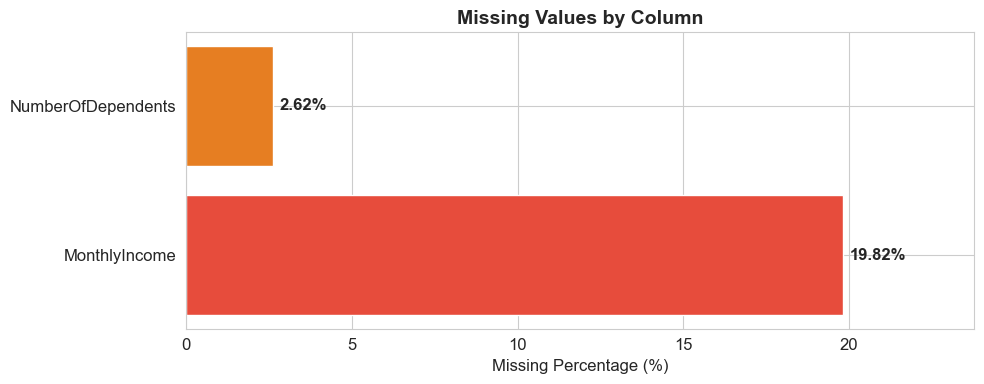

✅ Chart saved as missing_values.png


In [10]:
# Visualize missing values — much easier to understand than numbers alone
fig, ax = plt.subplots(figsize=(10, 4))

cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
bars = ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color=['#e74c3c', '#e67e22'])

# Add percentage labels on bars
for bar, pct in zip(bars, cols_with_missing['Missing %']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontweight='bold')

ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(cols_with_missing['Missing %']) * 1.2)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as missing_values.png')

### ✍️ YOUR OBSERVATIONS — Missing Values

- `MonthlyIncome` has ___% missing. This is significant — nearly 1 in 5 borrowers has no income recorded.
- `NumberOfDependents` has ___% missing. This might mean 0 dependents was left blank instead of filled as 0.

**Questions to answer on Day 2:**
1. Are missing income values related to higher default rates? (Missing income = hiding something?)
2. Should we impute MonthlyIncome with median or something smarter?
3. Should NumberOfDependents missing = 0 ?

---
## SECTION 7 — Target Variable Analysis

The target is `SeriousDlqin2yrs` — 1 means defaulted, 0 means did not.

This is the MOST important column. We need to understand:
- How many defaults vs non-defaults?
- Is the data balanced or imbalanced?

> 💡 **Why it matters:** If 93% of people didn't default, a model that just says "no default" for everyone gets 93% accuracy. That's useless. This is called the **accuracy paradox** — a key interview concept.

In [11]:
target_col = 'SeriousDlqin2yrs'

counts = df[target_col].value_counts()
pcts = df[target_col].value_counts(normalize=True) * 100

print('=== TARGET VARIABLE DISTRIBUTION ===')
print(f'No Default (0): {counts[0]:,} rows ({pcts[0]:.1f}%)')
print(f'Default    (1): {counts[1]:,} rows ({pcts[1]:.1f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

=== TARGET VARIABLE DISTRIBUTION ===
No Default (0): 139,974 rows (93.3%)
Default    (1): 10,026 rows (6.7%)
Imbalance ratio: 14.0:1


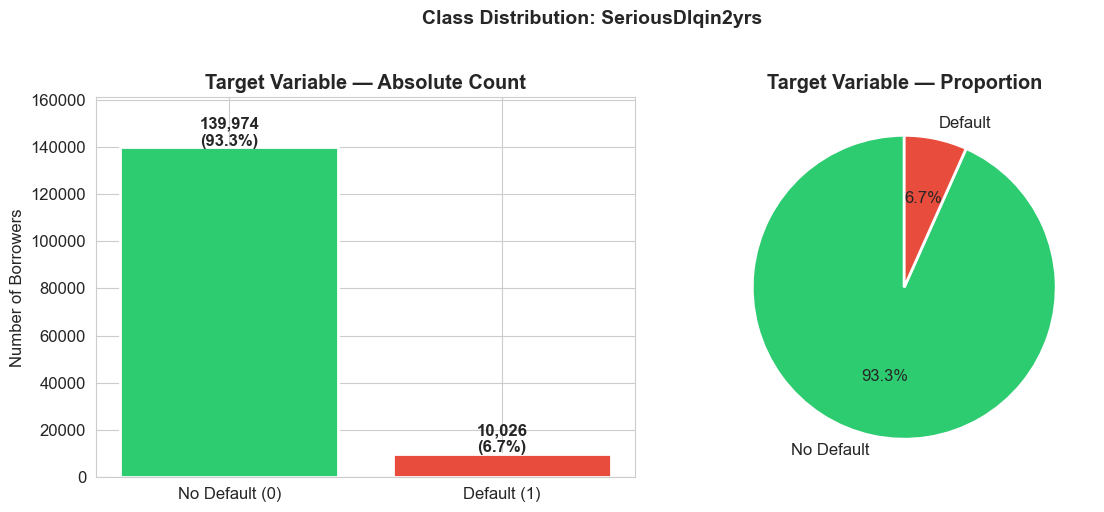

✅ Chart saved as target_distribution.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
ax1.bar(['No Default (0)', 'Default (1)'], counts.values, color=colors, edgecolor='white', linewidth=2)
for i, (val, pct) in enumerate(zip(counts.values, pcts.values)):
    ax1.text(i, val + 500, f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax1.set_title('Target Variable — Absolute Count', fontweight='bold')
ax1.set_ylabel('Number of Borrowers')
ax1.set_ylim(0, max(counts.values) * 1.15)

# Pie chart
ax2.pie(counts.values, labels=['No Default', 'Default'],
        colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Target Variable — Proportion', fontweight='bold')

plt.suptitle('Class Distribution: SeriousDlqin2yrs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as target_distribution.png')

### ✍️ YOUR OBSERVATIONS — Target Variable

- Default rate is approximately ___% — this dataset is **highly imbalanced**.
- The imbalance ratio is ___:1 (non-default to default)

**What this means for modeling (write in your own words):**
- We CANNOT use accuracy as our metric → we must use AUC-ROC or F1
- We will need to handle imbalance (SMOTE on Day 8)
- A dumb model that predicts 0 for everyone would get ___% accuracy — that's why accuracy is misleading here

> 🎯 **Interview line you can now say:** *"This dataset had a class imbalance of about 14:1. Using accuracy here would be misleading — a model that never predicts default achieves 93% accuracy but catches zero actual defaulters. So I optimized for AUC-ROC instead."*

---
## SECTION 8 — Quick Distribution Plots (Bonus if time permits)

Plot distributions of all numeric features to get a visual intuition.
This helps us spot skewness and extreme outliers at a glance.

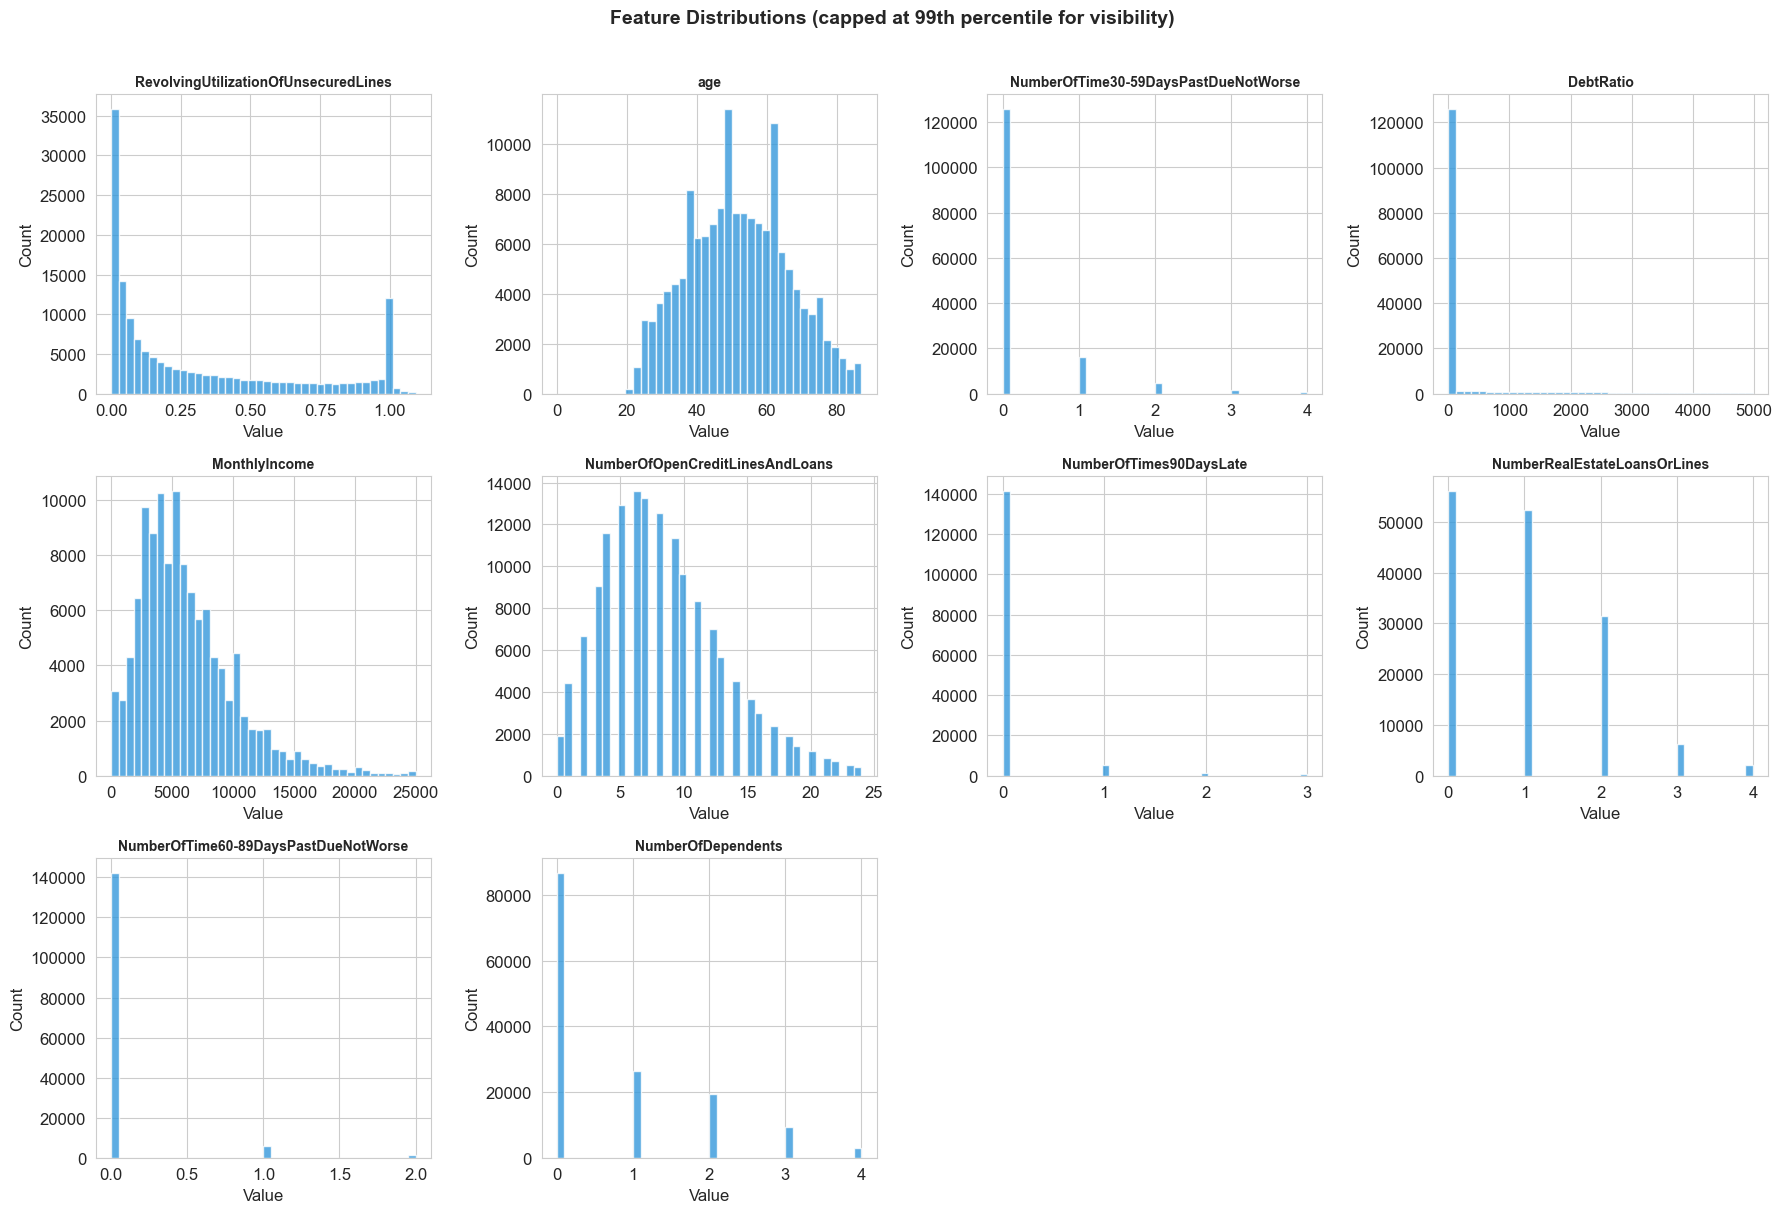

✅ Chart saved as feature_distributions.png


In [13]:
# Plot all feature distributions in a grid
feature_cols = [c for c in df.columns if c != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    # Remove extreme outliers just for visualization (99th percentile cap)
    data = df[col].dropna()
    cap = data.quantile(0.99)
    data_capped = data[data <= cap]
    
    axes[i].hist(data_capped, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (capped at 99th percentile for visibility)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as feature_distributions.png')

---
## SECTION 9 — Day 1 Summary & Notes for Tomorrow

Fill this out before closing the notebook. This becomes your **data diary**.

In [14]:
print('=' * 55)
print('         DAY 1 SUMMARY REPORT')
print('=' * 55)
print(f'Dataset shape     : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Target balance    : {pcts[0]:.1f}% no-default / {pcts[1]:.1f}% default')
print(f'Columns w/ missing: {(df.isnull().sum() > 0).sum()}')
print(f'Total missing vals: {df.isnull().sum().sum():,}')
print(f'Numeric columns   : {df.select_dtypes(include=np.number).shape[1]}')
print(f'Categorical cols  : {df.select_dtypes(include="object").shape[1]}')
print('=' * 55)
print()
print('FILES SAVED TODAY:')
print('  ✅ missing_values.png')
print('  ✅ target_distribution.png')
print('  ✅ feature_distributions.png')
print()
print('TASKS FOR DAY 2:')
print('  → Deep dive into missing values')
print('  → Visualize missingness pattern with missingno')
print('  → Decide imputation strategy per column')
print('  → Check if missing income correlates with default rate')

         DAY 1 SUMMARY REPORT
Dataset shape     : 150,000 rows × 11 columns
Target balance    : 93.3% no-default / 6.7% default
Columns w/ missing: 2
Total missing vals: 33,655
Numeric columns   : 11
Categorical cols  : 0

FILES SAVED TODAY:
  ✅ missing_values.png
  ✅ target_distribution.png
  ✅ feature_distributions.png

TASKS FOR DAY 2:
  → Deep dive into missing values
  → Visualize missingness pattern with missingno
  → Decide imputation strategy per column
  → Check if missing income correlates with default rate


### ✍️ YOUR PERSONAL NOTES (fill after completing Day 1)

**What surprised me today:**
*(write here)*

**Questions I have:**
*(write here — Google these or ask Claude)*

**One thing I want to explore more:**
*(write here)*

---
> ✅ **Day 1 Complete.** You now know your dataset better than 80% of candidates who just run models without understanding the data. See you on Day 2.